<a href="https://colab.research.google.com/github/Insight-Syndicate/DSPL_GCW/blob/main/Models/Logistic_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import auth
from googleapiclient.discovery import build

# Authenticate and build Google Drive API service
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Public Google Drive folder and file name
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"
file_name = "clean_train.csv"

# Search for the file
results = drive_service.files().list(q=f"'{folder_id}' in parents and name='{file_name}'",
                                     fields="files(id)").execute()
files = results.get("files", [])

if files:
    clean_train = pd.read_csv(f"https://drive.google.com/uc?id={files[0]['id']}")
    print(clean_train)
else:
    print(f"'{file_name}' not found in the folder.")

        Customer_ID outlet_city  luxury_sales  fresh_sales  dry_sales  \
0        10493832.0    Kelaniya       1209.60       756.00    5292.00   
1        10178643.0    Moratuwa       1590.12      1060.08    6007.12   
2        10513916.0     Wattala       2288.88      1481.04    9155.52   
3        10334589.0     Wattala       2274.94      1739.66    9099.76   
4        10458365.0    Kelaniya       2345.49      2069.55    9243.99   
...             ...         ...           ...          ...        ...   
774140   10197979.0     Gampaha       3893.40      3893.40    3448.44   
774141   10494575.0  Katunayake       6095.86      5557.99    6275.15   
774142   10565682.0     Colombo       5121.42      4820.16    4669.53   
774143   10351977.0       Kandy       6311.76      6311.76    5940.48   
774144   10637635.0     Negombo       5833.50      6027.95    6611.30   

        cluster_catgeory  outlet_city_encoded  
0                      4                   11  
1                      1   

# **Data Scaling**

## **Train**

We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [ ]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_train[numerical_columns] = DSPL_scaler.fit_transform(clean_train[numerical_columns])
clean_train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,-0.449457,-0.514864,0.291089,4,11
1,10178643.0,Moratuwa,-0.111244,-0.454663,0.424165,1,13
2,10513916.0,Wattala,0.509826,-0.371322,1.010049,4,19
3,10334589.0,Wattala,0.497436,-0.320120,0.999672,4,19
4,10458365.0,Kelaniya,0.560142,-0.254809,1.026512,4,11
...,...,...,...,...,...,...,...
774140,10197979.0,Gampaha,1.935952,0.106275,-0.051979,3,4
774141,10494575.0,Katunayake,3.893537,0.435829,0.474042,3,10
774142,10565682.0,Colombo,3.027438,0.289754,0.175253,3,1
774143,10351977.0,Kandy,4.085433,0.585060,0.411764,3,9


# **Logistic Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [ ]:
# Define X and y variables
X = clean_train[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='saga', random_state=42)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='saga')

In [ ]:
# Predict using test data
y_pred = log_reg_model.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

Accuracy: 0.9628
MSE: 0.1801
R2: 0.9484


[[37718     2     0   155     0     1]
 [    2 30780     0     2     4   134]
 [    1     0  7443     0  2303     1]
 [  153     0     2 34212     3     0]
 [    1     0  2841     1  5118     1]
 [    0   140     3     3     3 33802]]


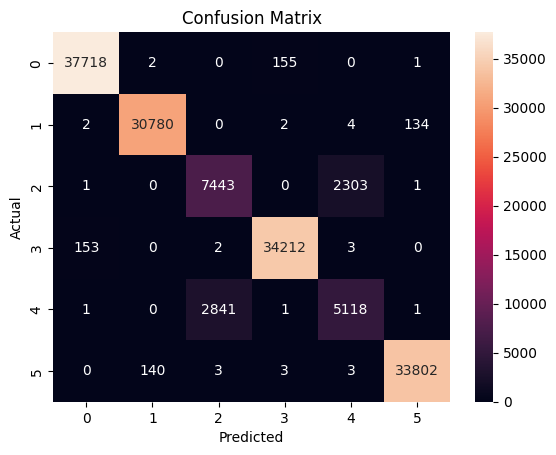

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       0.72      0.76      0.74      9748
           4       1.00      1.00      1.00     34370
           5       0.69      0.64      0.66      7962
           6       1.00      1.00      1.00     33951

    accuracy                           0.96    154829
   macro avg       0.90      0.90      0.90    154829
weighted avg       0.96      0.96      0.96    154829



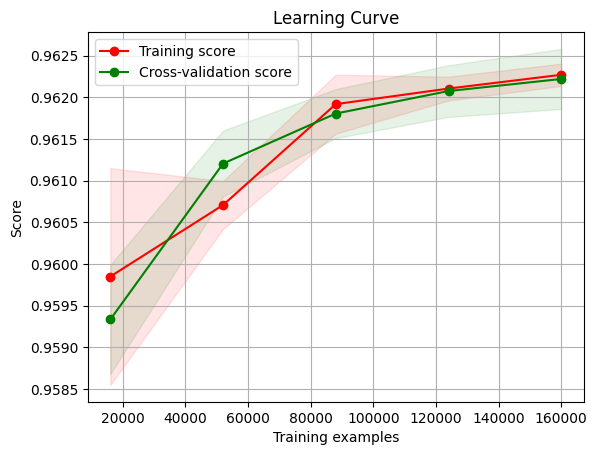

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=None, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, valid_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    valid_scores_mean = np.mean(valid_scores, axis=1)
    valid_scores_std = np.std(valid_scores, axis=1)

    plt.figure()
    plt.title("Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std, valid_scores_mean + valid_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, valid_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# Plot learning curve for Logistic Regression model with sample size of 200,000
sample_size = 200000
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = y[X_sample.index]

plot_learning_curve(log_reg_model, X_sample, y_sample, cv=5)
plt.show()

## **Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error

# Predict on training, validation, and test sets
y_train_pred = log_reg_model.predict(X_train)
y_val_pred = log_reg_model.predict(X_val)
y_test_pred = log_reg_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Determine if the model is overfitting or underfitting
if train_accuracy > val_accuracy and val_accuracy > test_accuracy:
    print("The model is overfitting.")
elif train_accuracy < val_accuracy:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 0.9629, Validation Accuracy: 0.9623, Test Accuracy: 0.9628
Training MSE: 0.1802, Validation MSE: 0.1836, Test MSE: 0.1801
The model is well-fitted.


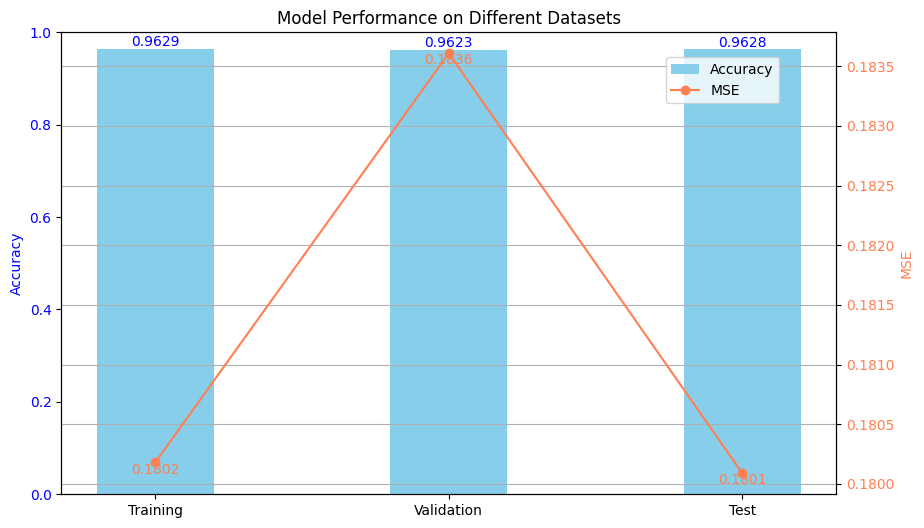

In [ ]:
# Data
datasets = ['Training', 'Validation', 'Test']
accuracy_scores = [train_accuracy, val_accuracy, test_accuracy]
mse_scores = [train_mse, val_mse, test_mse]

# Create subplots and second axis
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bar plot for Accuracy
bars = ax1.bar(datasets, accuracy_scores, color='skyblue', label='Accuracy', width=0.4)
ax1.set_ylabel('Accuracy', color='blue')
ax1.tick_params('y', labelcolor='blue')
ax1.set_ylim(0.0, 1.0)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', color="blue")

# Line plot for MSE
line = ax2.plot(datasets, mse_scores, color='coral', marker='o', label='MSE')
ax2.set_ylabel('MSE', color='coral')
ax2.tick_params('y', labelcolor='coral')
for i, value in enumerate(mse_scores):
    ax2.text(datasets[i], value, f'{value:.4f}', ha='center', va='top', color="coral")

# Set labels and title
plt.title('Model Performance on Different Datasets')
plt.xlabel('Dataset')

# Add grid and legend
plt.grid(True)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))

# Display the plot
plt.show()